In [ ]:
import json
from pathlib import Path

from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset

#### 1. connect to google drive and unzip dataset

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
print("Assuming ChartQA_Dataset.zip was downloaded to drive")

# replace the path with your own path
!unzip -q "/content/drive/MyDrive/646_datasets/ChartQA_Dataset.zip" -d /content/

In [ ]:
mv "/content/ChartQA Dataset" "/content/ChartQA_Dataset"

#### 2. DataLoader

In [ ]:
def _answer_to_str(label) -> str:
    if isinstance(label, list):
        return str(label[0]) if len(label) > 0 else ""
    if label is None:
        return ""
    return str(label)


class ChartQAHumanDataset(Dataset):
    """ChartQA examples from `*_human.json` (train_human.json or val_human.json)."""

    def __init__(self, split_dir: str | Path, json_name: str = "train_human.json"):
        self.split_dir = Path(split_dir)
        self.png_dir = self.split_dir / "png"
        json_path = self.split_dir / json_name
        if not json_path.is_file():
            raise FileNotFoundError(f"Missing {json_path}")
        if not self.png_dir.is_dir():
            raise FileNotFoundError(f"Missing png folder: {self.png_dir}")

        with open(json_path, encoding="utf-8") as f:
            self.items = json.load(f)

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, idx: int) -> dict:
        row = self.items[idx]
        imgname = row["imgname"]
        path = self.png_dir / imgname
        if not path.is_file():
            raise FileNotFoundError(f"Image not found: {path}")

        image = Image.open(path).convert("RGB")
        return {
            "image": image,
            "question": row["query"],
            "answer": _answer_to_str(row.get("label")),
            "imgname": imgname,
        }


def chartqa_human_collate_fn(batch: list[dict]) -> dict:
    """Batch as lists (PIL images need a VLM processor or custom stacking)."""
    return {
        "images": [b["image"] for b in batch],
        "questions": [b["question"] for b in batch],
        "answers": [b["answer"] for b in batch],
        "imgnames": [b["imgname"] for b in batch],
    }

In [ ]:
# Folder that contains train/, val/, test/ (each with png/ and *_human.json).
# Must exist on the SAME machine as the Jupyter kernel (Mac path won't work on Colab/Linux).
CHARTQA_ROOT = Path("/content/ChartQA_Dataset")
if not CHARTQA_ROOT.is_dir():
    raise FileNotFoundError(
        f"Not found: {CHARTQA_ROOT}\n"
        "If you use Colab/SSH/Docker, /Users/jenny/... does not exist there—upload the dataset "
        "or mount Drive and set CHARTQA_ROOT to that path. Or run Jupyter on your Mac."
    )

train_ds = ChartQAHumanDataset(CHARTQA_ROOT / "train", json_name="train_human.json")
val_ds = ChartQAHumanDataset(CHARTQA_ROOT / "val", json_name="val_human.json")
test_ds = ChartQAHumanDataset(CHARTQA_ROOT / "test", json_name="test_human.json")

train_loader = DataLoader(
    train_ds,

    batch_size=4,
    shuffle=False,
    num_workers=0,
    collate_fn=chartqa_human_collate_fn,
)

val_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=chartqa_human_collate_fn,
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=chartqa_human_collate_fn,
)

print("Number of training examples:", len(train_ds))
print("Number of validation examples:", len(val_ds))
print("Number of test examples:", len(test_ds))

Number of training examples: 7398
Number of validation examples: 960
Number of test examples: 1250


##### (Sanity check)

Which colour line has higher value than others from 2009 to 2014? ... orange


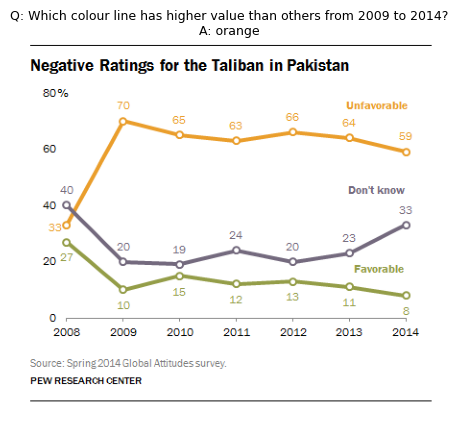

In [ ]:
# N = index of one training example
N = 300
ex = train_ds[N]
print(ex["question"][:80], "...", ex["answer"])
plt.imshow(ex["image"])
plt.axis("off")
plt.title(f"Q: {ex['question'][:100]}{'…' if len(ex['question']) > 100 else ''}\nA: {ex['answer']}", fontsize=9)
plt.show()

#### 3. Load VLM

In [ ]:
import torch
from tqdm.auto import tqdm
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16 if device == "cuda" else torch.float32,
    device_map="auto" if device == "cuda" else None,
)
if device != "cuda":
    model = model.to(device)
model.eval()

##### #functions: helper functions

In [ ]:
import re
from pathlib import Path

def normalize_em(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s


def exact_match(pred: str, gold: str) -> bool:
    return normalize_em(pred) == normalize_em(gold)


def inspect_chartqa_predictions(
    records: list[dict],
    *,
    chartqa_root: Path | None = None,
    split: str = "test",
    max_show: int = 5,
) -> None:
    """Plot up to ``max_show`` items from inference ``records`` (reloads PNGs from ChartQA layout)."""
    root = chartqa_root if chartqa_root is not None else CHARTQA_ROOT
    for n in range(min(max_show, len(records))):
        ex = records[n]
        print(ex["question"][:80], "...", ex["gold"], ex["pred"])

        image_path = root / split / "png" / ex["imgname"]
        image = Image.open(image_path)

        plt.imshow(image)
        plt.axis("off")
        plt.title(
            f"Q: {ex['question'][:100]}{'…' if len(ex['question']) > 100 else ''}\n"
            f"A: {ex['gold']} | pred: {ex['pred']} | EM:{ex['exact_match']}",
            fontsize=9,
        )
        plt.show()


##### #functions: inference function

In [ ]:
# inference
import json
import re
from pathlib import Path

import torch
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset

def run_chartqa_inference(
    data,
    model,
    processor,
    device,
    prompt: str,
    dataset_name: str,
    save_file: bool = False,
    *,
    max_samples: int | None = None,
    max_new_tokens: int = 128,
    batch_size: int | None = None,
    collate_fn=None,
    num_workers: int = 0,
) -> tuple[float, list[dict]]:
    """Run Qwen2-VL on ChartQA via a ``DataLoader`` or a ``Dataset``.

    Batches must provide ``images``, ``questions``, ``answers``, ``imgnames`` (see ``chartqa_human_collate_fn``).
    If ``data`` is a Dataset, a DataLoader is built (``batch_size`` default 1, ``collate_fn`` default chartqa).
    """

    # prepare dataloader
    if isinstance(data, DataLoader):
        dataloader = data
    elif isinstance(data, Dataset):
        bs = batch_size if batch_size is not None else 1
        fn = collate_fn if collate_fn is not None else chartqa_human_collate_fn
        dataloader = DataLoader(
            data,
            batch_size=bs,
            shuffle=False,
            num_workers=num_workers,
            collate_fn=fn,
        )
    else:
        raise TypeError(
            "data must be a DataLoader or Dataset, got " + type(data).__name__
        )

    n_total = len(dataloader.dataset)
    n_target = n_total if max_samples is None else min(max_samples, n_total)

    records: list[dict] = []
    correct = 0
    n_done = 0

    # run inference
    for batch in tqdm(dataloader, desc=f"{dataset_name} inference"):
        if n_done >= n_target:
            break

        images = batch["images"]
        questions = batch["questions"]
        answers = batch["answers"]
        imgnames = batch["imgnames"]

        take = min(len(images), n_target - n_done)
        if take <= 0:
            break

        images_b = images[:take]
        questions_b = questions[:take]
        answers_b = answers[:take]
        imgnames_b = imgnames[:take]

        text_prompts: list[str] = []
        for j in range(take):
            q = questions_b[j] + prompt
            conversation = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image"},
                        {"type": "text", "text": q},
                    ],
                }
            ]
            text_prompts.append(
                processor.apply_chat_template(conversation, add_generation_prompt=True)
            )

        inputs = processor(
            text=text_prompts,
            images=images_b,
            padding=True,
            return_tensors="pt",
        )
        inputs = inputs.to(device)
        with torch.inference_mode():
            output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)

        in_len = inputs.input_ids.shape[1]
        new_tokens = output_ids[:, in_len:]
        preds = processor.batch_decode(
            new_tokens,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=True,
        )

        # post-process predictions
        for j in range(take):
            pred = preds[j].strip()
            gold = answers_b[j]
            ok = exact_match(pred, gold)
            correct += int(ok)
            records.append(
                {
                    "imgname": imgnames_b[j],
                    "question": questions_b[j],
                    "gold": gold,
                    "pred": pred,
                    "exact_match": ok,
                }
            )
            n_done += 1

    # calculate accuracy
    n = n_done
    em = correct / n if n else 0.0
    print(f"[{dataset_name}] EM ({n} examples): {em:.4f}")

    # save predictions
    if save_file:
        safe_name = re.sub(r"[^\w\-]+", "_", dataset_name).strip("_") or "split"
        out_path = Path(f"{safe_name}_accuracy_{em:.4f}.jsonl")
        with open(out_path, "w", encoding="utf-8") as f:
            for r in records:
                f.write(json.dumps(r, ensure_ascii=False) + "\n")
        print("Saved:", out_path.resolve())

    return em, records


##### 3. RUN! Baseline inference and visualization

In [ ]:
# 0. baseline prompt
Baseline_PROMPT = (
    "\nAnswer with only the final answer: a short phrase or a number. No explanation."
)

# Full split is slow; use max_samples=50 to debug.
val_em, records = run_chartqa_inference(
    val_loader,
    model,
    processor,
    device,
    Baseline_PROMPT,
    dataset_name="val",
    save_file=False,
    max_samples=None,
)


In [ ]:
inspect_chartqa_predictions(records, split="val", max_show=40)